
# Basketball Coach Awards — Data Discovery & Visualization




In [41]:

import pandas as pd
import matplotlib.pyplot as plt




In [43]:

# ---- Load Data ----
CSV_PATH = "archive/basketball_awards_coaches.csv"
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nSample rows:")
display(df.head(5))


Shape: (61, 5)
Columns: ['year', 'coachID', 'award', 'lgID', 'note']

Dtypes:
 year        int64
coachID    object
award      object
lgID       object
note       object
dtype: object

Sample rows:


,year,coachID,award,lgID,note
0,1962,gallaha01,NBA Coach of the Year,NBA,NaN
1,1963,hannual01,NBA Coach of the Year,NBA,NaN
2,1964,auerbre01,NBA Coach of the Year,NBA,NaN
3,1965,schaydo01,NBA Coach of the Year,NBA,NaN
4,1966,kerrjo01,NBA Coach of the Year,NBA,NaN


In [45]:

# ---- Data Discovery ----
missing = df.isna().sum().sort_values(ascending=False)
print("Missing values by column:\n", missing)

df.describe()

Missing values by column:
 note       57
year        0
coachID     0
award       0
lgID        0
dtype: int64


,year
count,61.000000
mean,1983.704918
std,14.518200
min,1962.000000
25%,1971.000000
50%,1981.000000
75%,1996.000000
max,2011.000000


In [47]:

# ---- Clean 'note' Column ----
if 'note' in df.columns:
    df['note'] = df['note'].fillna("No note")
    print("Filled NaN values in 'note' with 'No note'.")
else:
    print("Column 'note' not found — skipping fillna.")


Filled NaN values in 'note' with 'No note'.


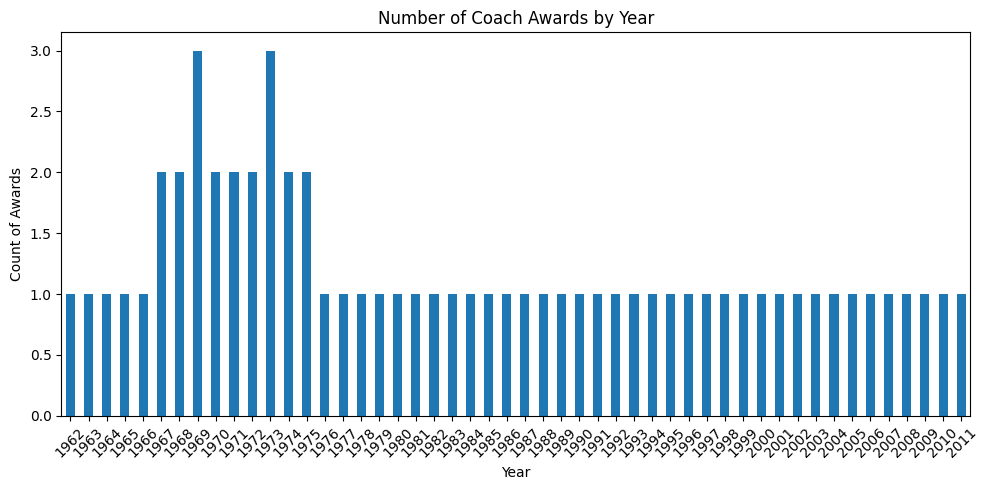

In [49]:

# ---- Visualization 1: Awards per year ----
plt.figure(figsize=(10, 5))
df['year'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Coach Awards by Year")
plt.xlabel("Year")
plt.ylabel("Count of Awards")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


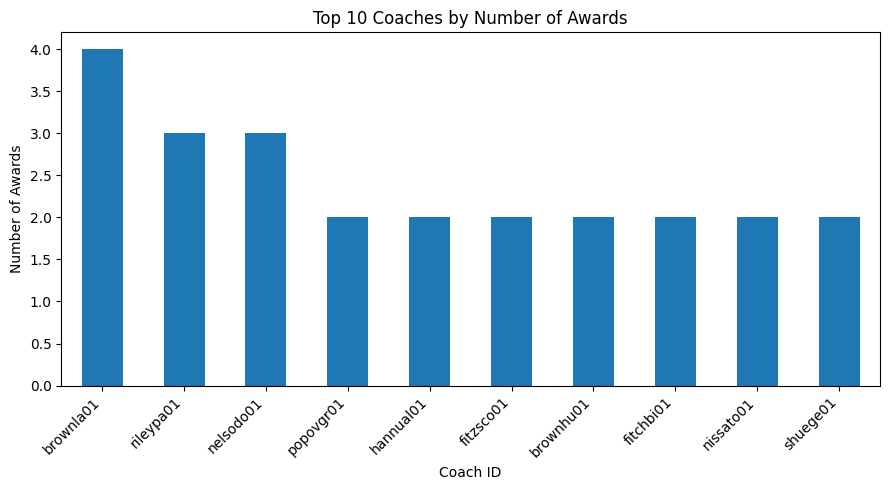

In [51]:

# ---- Visualization 2: Top 10 Coaches by Number of Awards ----
plt.figure(figsize=(9, 5))
df['coachID'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Coaches by Number of Awards")
plt.xlabel("Coach ID")
plt.ylabel("Number of Awards")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


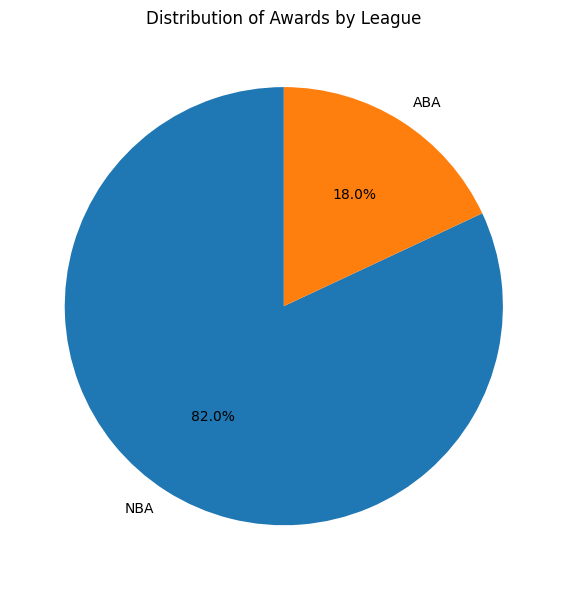

In [53]:

# ---- Visualization 3: Awards by League ----
plt.figure(figsize=(6, 6))
df['lgID'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Awards by League")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [55]:

# ---- Save cleaned dataset ----
OUTPUT_CSV = "archive/basketball_awards_coaches_clean.csv"
df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved cleaned CSV to: {OUTPUT_CSV}")


Saved cleaned CSV to: archive/basketball_awards_coaches_clean.csv


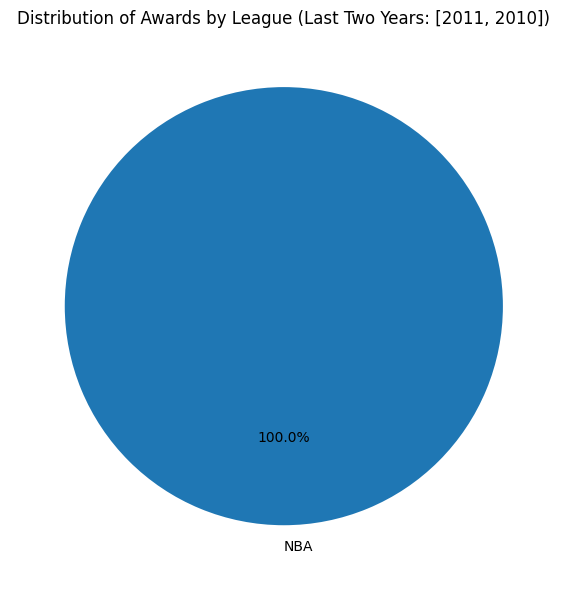

In [58]:
import matplotlib.pyplot as plt

# Find the last two years
last_two_years = df['year'].nlargest(2).tolist()

# Filter to only those years
df_last_two = df[df['year'].isin(last_two_years)]

# Plot pie chart
plt.figure(figsize=(6, 6))
df_last_two['lgID'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title(f"Distribution of Awards by League (Last Two Years: {last_two_years})")
plt.ylabel("")
plt.tight_layout()
plt.show()
